### Pipeline (YOLO → Swin Transformer)

**Mục tiêu**: Kết hợp YOLO detector + Swin Transformer classifier thành pipeline hoàn chỉnh.

**Flow**:
```
Ảnh đầu vào
    → YOLO detect()   → bounding boxes
    → crop mỗi bbox   → 224×224 crops
    → Swin classify() → {label, confidence%}
    → Vẽ kết quả
```

In [1]:
# Google Colab Setup 
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics transformers torch torchvision opencv-python-headless -q


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Imports 
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from ultralytics import YOLO
from transformers import SwinForImageClassification
from torchvision import transforms
from PIL import Image

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

BASE_DIR = Path("/content/drive/MyDrive/DATN")


Device: cuda


In [3]:
# Load YOLO
YOLO_WEIGHTS = BASE_DIR / 'models' / 'yolo_detect_v4' / 'weights' / 'best.pt'
yolo_model   = YOLO(str(YOLO_WEIGHTS))
print(f"YOLO loaded: {YOLO_WEIGHTS.name}")
print(f"   Classes: {yolo_model.names}")


YOLO loaded: best.pt
   Classes: {0: 'item'}


In [4]:
# Load Swin Transformer
SWIN_WEIGHTS = BASE_DIR / 'models' / 'swin_classifier.pth'

ckpt        = torch.load(str(SWIN_WEIGHTS), map_location=DEVICE, weights_only=False)
CLASS_NAMES = ckpt['class_names']
MODEL_CKPT  = ckpt.get('model_ckpt', 'microsoft/swin-small-patch4-window7-224')
NUM_CLASSES = ckpt.get('num_labels', len(CLASS_NAMES))

swin_model = SwinForImageClassification.from_pretrained(
    MODEL_CKPT,
    num_labels=NUM_CLASSES,
    id2label={str(i): n for i, n in enumerate(CLASS_NAMES)},
    label2id={n: i for i, n in enumerate(CLASS_NAMES)},
    ignore_mismatched_sizes=True,
)
swin_model.load_state_dict(ckpt['model_state'])
swin_model.to(DEVICE).eval()

val_acc_str = f"{ckpt['val_acc']:.4f}" if 'val_acc' in ckpt else 'N/A'
print(f"Swin loaded: {SWIN_WEIGHTS.name}")
print(f"   Model   : {MODEL_CKPT}")
print(f"   Epoch   : {ckpt['epoch']} | Val acc: {val_acc_str}")
print(f"   Classes : {NUM_CLASSES}  —  {CLASS_NAMES[:4]} ...")

# Transform cho Swin
swin_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/199M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/449 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/199M [00:00<?, ?B/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-small-patch4-window7-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([38, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([38])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Swin loaded: swin_classifier.pth
   Model   : microsoft/swin-small-patch4-window7-224
   Epoch   : 50 | Val acc: 0.9994
   Classes : 38  —  ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy'] ...


In [5]:
# Pipeline: YOLO detect -> crop -> Swin classify
def predict_pipeline(img_path, yolo_conf_thresh=0.25, top_k=3):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H, W    = img_rgb.shape[:2]

    yolo_results = yolo_model(str(img_path), conf=yolo_conf_thresh, verbose=False)[0]
    detections   = []

    for box in yolo_results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        yolo_conf = float(box.conf)

        margin = 0.05
        pad_x  = int((x2 - x1) * margin)
        pad_y  = int((y2 - y1) * margin)
        crop   = img_rgb[max(0, y1-pad_y):min(H, y2+pad_y),
                         max(0, x1-pad_x):min(W, x2+pad_x)]
        if crop.size == 0:
            continue

        pil_crop = Image.fromarray(crop)
        tensor   = swin_transform(pil_crop).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = swin_model(pixel_values=tensor).logits
            probs  = torch.softmax(logits, dim=1)[0].cpu().numpy()

        top_indices = np.argsort(probs)[::-1][:top_k]
        topk_list   = [(CLASS_NAMES[i], float(probs[i])) for i in top_indices]

        detections.append({
            'bbox'       : [x1, y1, x2, y2],
            'yolo_conf'  : yolo_conf,
            'swin_label' : topk_list[0][0],
            'swin_conf'  : topk_list[0][1],
            'swin_topk'  : topk_list,
        })

    return {'image': img_rgb, 'detections': detections}

print(f"Pipeline: YOLO detect + Swin classify {NUM_CLASSES} classes")

Pipeline: YOLO detect + Swin classify 38 classes


In [6]:

# Visualize kết quả
def visualize_result(result: dict, title: str = '', figsize: tuple = (12, 8)):
    img  = result['image'].copy()
    dets = result['detections']

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(img)

    colors = plt.cm.tab20.colors  # 20 distinct colors
    for i, det in enumerate(dets):
        x1, y1, x2, y2 = det['bbox']
        color    = colors[i % len(colors)]
        label    = f"{det['swin_label']} {det['swin_conf']:.0%}"
        sublabel = f"(YOLO conf: {det['yolo_conf']:.0%})"

        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2.5, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, max(0, y1 - 18), label,
                color='white', fontsize=9, fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.85, pad=2, boxstyle='round'))
        ax.text(x1, y2 + 5, sublabel,
                color=color, fontsize=7, alpha=0.9)

    n = len(dets)
    ax.set_title(f"{title}  — {n} detection{'s' if n != 1 else ''} found", fontsize=11)
    ax.axis('off')
    plt.tight_layout()
    return fig



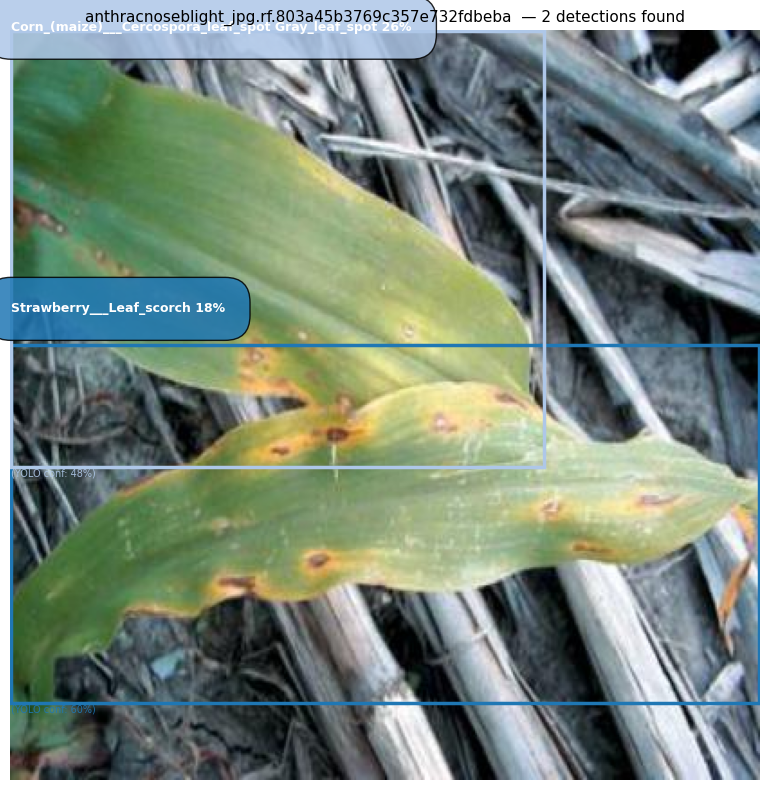

  → 2 detections:
     [Strawberry___Leaf_scorch] conf=18.4% (YOLO conf: 59.9%)
     [Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot] conf=26.3% (YOLO conf: 48.5%)



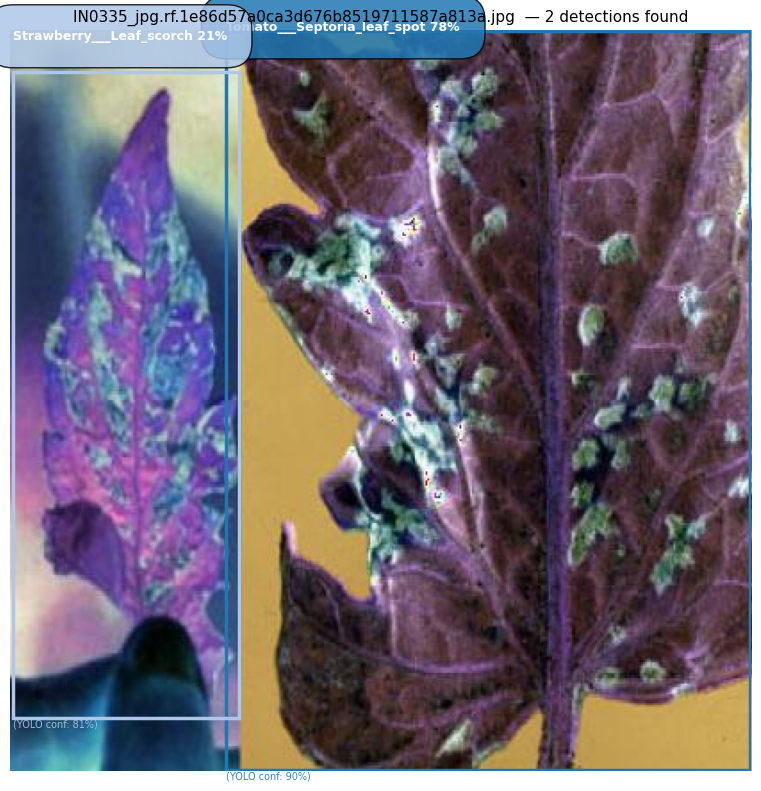

  → 2 detections:
     [Tomato___Septoria_leaf_spot] conf=77.6% (YOLO conf: 90.4%)
     [Strawberry___Leaf_scorch] conf=21.2% (YOLO conf: 81.1%)



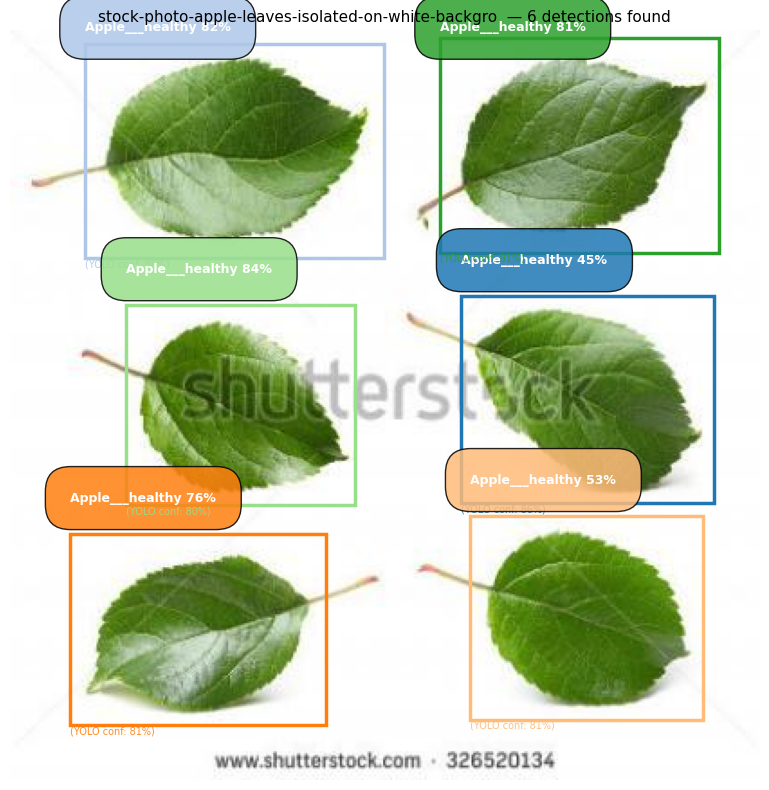

  → 6 detections:
     [Apple___healthy] conf=44.7% (YOLO conf: 86.1%)
     [Apple___healthy] conf=82.4% (YOLO conf: 85.9%)
     [Apple___healthy] conf=75.5% (YOLO conf: 81.3%)
     [Apple___healthy] conf=53.2% (YOLO conf: 80.6%)
     [Apple___healthy] conf=80.5% (YOLO conf: 80.6%)
     [Apple___healthy] conf=84.0% (YOLO conf: 79.9%)



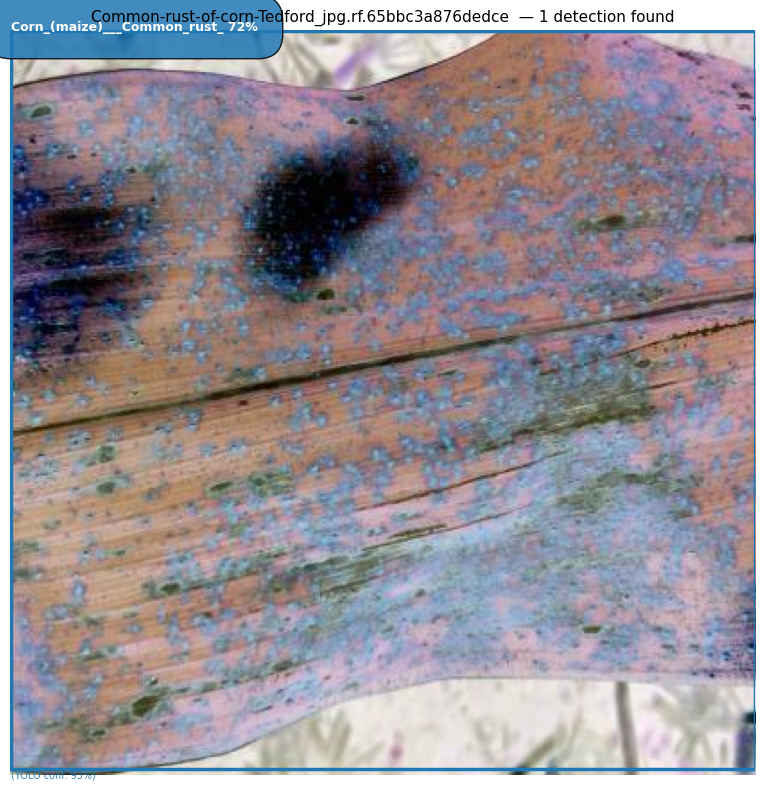

  → 1 detections:
     [Corn_(maize)___Common_rust_] conf=71.6% (YOLO conf: 92.9%)



In [7]:
# Test trên ảnh từ tập Test
import random

test_imgs = list((BASE_DIR / "plant disease.v1i.yolov11" / "test" / "images").glob("*.jpg"))
samples   = random.sample(test_imgs, min(4, len(test_imgs)))

for img_path in samples:
    result = predict_pipeline(str(img_path))
    fig    = visualize_result(result, title=img_path.name[:50])
    plt.savefig(str(BASE_DIR / f'pred_{img_path.stem}.png'), dpi=120)
    plt.show()
    print(f"  → {len(result['detections'])} detections:")
    for d in result['detections']:
        print(f"     [{d['swin_label']}] conf={d['swin_conf']:.1%} "
              f"(YOLO conf: {d['yolo_conf']:.1%})")
    print()
